# TensorFlow Delaney Regression Baseline

This notebook mirrors the Delaney regression baseline in TensorFlow/Keras with a compact dense network over standardized descriptors.

In [84]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [85]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))
delaney = pd.read_csv(DATA_DIR / "delaney-processed.csv")
feature_columns = [
    "ESOL predicted log solubility in mols per litre",
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
target_column = "measured log solubility in mols per litre"
display(delaney.head())

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [86]:
X = delaney[feature_columns]
y = delaney[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED
)

normalizer = tf.keras.layers.Normalization()
normalizer.adapt(X_train.to_numpy().astype("float32"))

train_ds = (
    tf.data.Dataset.from_tensor_slices(
        (X_train.to_numpy().astype("float32"), y_train.to_numpy().astype("float32"))
    )
    .shuffle(len(X_train), seed=RANDOM_SEED)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)
valid_ds = (
    tf.data.Dataset.from_tensor_slices(
        (X_valid.to_numpy().astype("float32"), y_valid.to_numpy().astype("float32"))
    )
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)
test_features = X_test.to_numpy().astype("float32")

In [87]:
model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(len(feature_columns),)),
        normalizer,
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

history = model.fit(train_ds, validation_data=valid_ds, epochs=120, verbose=0)
history_df = pd.DataFrame(history.history)
display(history_df.tail().round(4))

,loss,mae,val_loss,val_mae
115,0.3253,0.4245,0.4203,0.4610
116,0.3084,0.4149,0.4256,0.4592
117,0.3118,0.4128,0.4275,0.4624
118,0.3105,0.4153,0.4091,0.4491
119,0.3065,0.4085,0.4254,0.4588


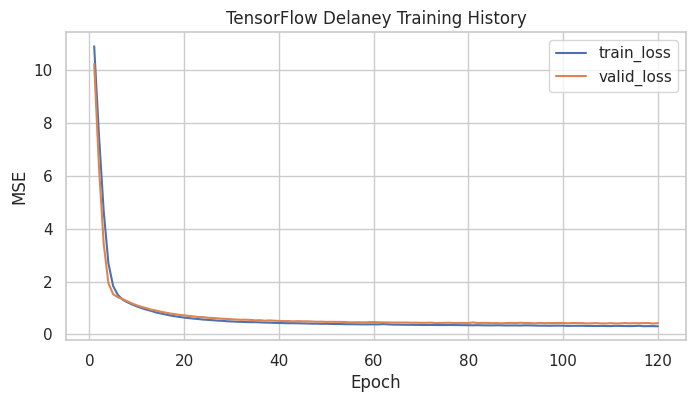

In [88]:
plt.figure(figsize=(8, 4))
plt.plot(history_df.index + 1, history_df["loss"], label="train_loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="valid_loss")
plt.title("TensorFlow Delaney Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [89]:
valid_prediction = model.predict(
    X_valid.to_numpy().astype("float32"), verbose=0
).ravel()
valid_metrics = pd.DataFrame(
    [
        {
            "rmse": float(np.sqrt(mean_squared_error(y_valid, valid_prediction))),
            "mae": float(mean_absolute_error(y_valid, valid_prediction)),
            "r2": float(r2_score(y_valid, valid_prediction)),
        }
    ]
)
display(valid_metrics.round(4))

test_prediction = model.predict(test_features, verbose=0).ravel()
test_metrics = pd.DataFrame(
    [
        {
            "rmse": float(np.sqrt(mean_squared_error(y_test, test_prediction))),
            "mae": float(mean_absolute_error(y_test, test_prediction)),
            "r2": float(r2_score(y_test, test_prediction)),
        }
    ]
)
display(test_metrics.round(4))

,rmse,mae,r2
0,0.6523,0.4588,0.9155


,rmse,mae,r2
0,0.7006,0.4845,0.8798
